> **Frozen research record (2026-07-01).** This notebook documents the research phase end-to-end — EDA, the reporting-lag investigation, feature engineering, target construction, the valuation-gap model, and the back-test — with outputs preserved. It is kept as a record and is **not re-executed**: cells import from the pre-refactor `src/` layout and reference absolute local paths. The reproducible path is the `neighbourhood_pulse` package: `pulse ingest → pulse transform → pulse train`.

# Neighbourhood Pulse: Exploratory Data Analysis

In [ ]:
import pandas as pd

sample = pd.read_csv('C:\\Users\\Aniket\\Documents\\Projects\\Neighbourhood_Pulse\\data\\raw\\pp-2021.csv', header=None, nrows=5)
print(sample)

                                       0       1                 2         3   \
0  {D22473F5-3802-7B40-E053-6C04A8C0A630}  230000  2021-06-09 00:00  CO13 0PQ   
1  {D22473F5-3803-7B40-E053-6C04A8C0A630}  700000  2021-06-25 00:00  IG10 4BS   
2  {D22473F5-3804-7B40-E053-6C04A8C0A630}  625000  2021-06-28 00:00   EN9 1LH   
3  {D22473F5-3805-7B40-E053-6C04A8C0A630}  360000  2021-02-17 00:00   SS9 3AU   
4  {D22473F5-3806-7B40-E053-6C04A8C0A630}  345000  2021-06-25 00:00  SS15 6BG   

  4  5  6    7   8                 9            10              11  \
0  D  N  F    4 NaN     BELLAMY CLOSE  KIRBY CROSS  FRINTON-ON-SEA   
1  T  N  F   70 NaN       SMARTS LANE          NaN        LOUGHTON   
2  S  N  F    7 NaN       THE COBBINS          NaN   WALTHAM ABBEY   
3  S  N  F  117 NaN   FLEMMING AVENUE          NaN    LEIGH-ON-SEA   
4  S  N  F    2 NaN  BROADWATER GREEN      LAINDON        BASILDON   

                12               13 14 15  
0         TENDRING            ESSEX  A  A  
1   

: 

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import folium

In [2]:
data = pd.read_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw/planning_applications.parquet")
coffee = gpd.read_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw/coffee_shops.parquet")

planning_processed = gpd.read_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/planning_processed.parquet")
coffee_processed = gpd.read_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/coffee_shops_processed.parquet")

## 2. Data Quality Investigation  

In [3]:
data.head()

,lpa_name,uprn,decision,application_type,postcode,locality,description,borough,centroid_northing,ward,...,url_planning_app,lpa_app_no,polygon,appeal_decision_date,appeal_decision,id,site_number,centroid_easting,status,application_details
0,Newham,000046073734,<NA>,All Other,E13 0PD,Plaistow,Proposed conversion of property into a small HMO.,London Borough of Newham,183567,PNORTH,...,<NA>,24/01354/COU,"{'coordinates': None, 'crs': None, 'geometries...",<NA>,<NA>,Newham-24_01354_COU,88,540597,Application Under Consideration,None
1,Newham,000046019951,Approved,Householder,E7 0HB,Forest Gate,Erection of a rear dormer roof extension and i...,London Borough of Newham,185741,FGNTH,...,<NA>,23/01626/HH,"{'coordinates': None, 'crs': None, 'geometries...",<NA>,<NA>,Newham-23_01626_HH,16,540571,Approved,None
2,Newham,000046079327,Approved,All Other,E6 6EA,East Ham,Application for a lawful development certifica...,London Borough of Newham,183133,EHCENT,...,<NA>,21/01161/CLP,"{'coordinates': None, 'crs': None, 'geometries...",<NA>,<NA>,Newham-21_01161_CLP,148,542928,Approved,{'residential_details': {'affordable_percentag...
3,Newham,000046252014,Approved,All Other,E16 1XL,Canning Town,Approval of details pursuant to Condition 20 (...,London Borough of Newham,180751,CH,...,<NA>,22/00770/AOD,None,<NA>,<NA>,Newham-22_00770_AOD,1,540883,Approved,None
4,Newham,010096296777,Approved,All Other,E16 3SA,Canning Town,Approval of details pursuant to Condition 9 (D...,London Borough of Newham,181164,CH,...,<NA>,24/00957/AOD,"{'coordinates': None, 'crs': None, 'geometries...",<NA>,<NA>,Newham-24_00957_AOD,,540700,Approved,None


### British National Grid - coordinates typically spanning from 0,0 to 700,000,300,000 meters (Easting, Northing).

In [4]:
print(data['centroid_easting'].min())
print(data['centroid_easting'].max())

-4722
548530


In [5]:
print(data['centroid_northing'].min())
print(data['centroid_northing'].max())

0
6735746


In [6]:
print(data['centroid_easting'].argmin())

42411


In [7]:
print(data.at[42411, "centroid_northing"])

6725758


##### These is a value (centroid_easting, centroid_northing) = (-4722, 6725758)

<b>Finding:</b> centroid_easting and centroid_northing are in British National Grid 
(EPSG:27700) for valid records. Approximately X records have coordinates 
outside valid UK BNG ranges and will be filtered during transformation.

### The coordinate range checks

In [8]:
valid_bng = data[
    (data['centroid_easting'] >= 0) & 
    (data['centroid_easting'] <= 700000) &
    (data['centroid_northing'] >= 0) & 
    (data['centroid_northing'] <= 1300000)
]
print(f"Valid records: {len(valid_bng)} out of {len(data)}")

Valid records: 36553 out of 46036


### Create a GeoDataFrame with your single mystery point

In [9]:
test_df = gpd.GeoDataFrame(
    index=[0], 
    geometry=[Point(-4722, 6725758)], 
    crs="EPSG:3857" # Explicitly tell it this is Web Mercator
)

# Project it to standard Latitude/Longitude
test_df_latlon = test_df.to_crs("EPSG:4326")

print(test_df_latlon.geometry.iloc[0])

POINT (-0.0424184477161238 51.58681304154209)


##### <b>Finding: Mixed Coordinate Systems </b>
~20% of planning records contained invalid BNG coordinates, 
hypothesised to be incorrectly stored in Web Mercator (EPSG:3857) 
by certain boroughs. These records were filtered during transformation.

### Geometry type check (Point/Polygon/MultiPolygon)

In [10]:
coffee = gpd.read_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw/coffee_shops.parquet")
print(coffee.geometry.geom_type.value_counts())

Point           4620
Polygon         2068
MultiPolygon       1
Name: count, dtype: int64


### CRS validation

In [11]:
print(coffee.geometry.head())
print(coffee.crs)

element  id      
node     20849687    POINT (-0.33402 51.41101)
         25475389    POINT (-0.12925 51.52658)
         25497832    POINT (-0.11611 51.52476)
         25991205     POINT (-0.07248 51.5509)
         26269218    POINT (-0.05986 51.56915)
Name: geometry, dtype: geometry
{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG"

### List all the Columns from Coffee Shop Data to extract meaningful columns 

In [12]:
coffee = gpd.read_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw/coffee_shops.parquet")
print(coffee.columns.tolist())
print(coffee.head(2))

['geometry', 'amenity', 'note', 'operator', 'fixme', 'name', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'fhrs:id', 'toilets:wheelchair', 'wheelchair', 'addr:housename', 'addr:suburb', 'alt_name', 'check_date', 'contact:facebook', 'contact:twitter', 'diet:vegan', 'diet:vegetarian', 'dog', 'fhrs:local_authority_id', 'highchair', 'indoor_seating', 'internet_access', 'opening_hours', 'outdoor_seating', 'payment:credit_cards', 'payment:debit_cards', 'smoking', 'takeaway', 'website', 'source', 'source:postcode', 'addr:county', 'source:addr', 'brand', 'brand:wikidata', 'cuisine', 'bar', 'drive_through', 'level', 'payment:contactless', 'payment:mastercard', 'payment:visa', 'addr:country', 'brand:wikipedia', 'official_name', 'fhrs:confidence_management', 'fhrs:hygiene', 'fhrs:rating', 'fhrs:structural', 'wheelchair:description', 'fhrs:authority', 'contact:instagram', 'email', 'phone', 'toilets', 'toilets:access', 'created_by', 'former_name', 'survey:date', 'addr:place', 'o

## 3. Planning Data Overview

In [13]:
print(planning_processed.shape)
print(planning_processed.dtypes)
planning_processed.head()

(36553, 29)
lpa_name                string[python]
uprn                    string[python]
decision                string[python]
application_type        string[python]
postcode                string[python]
locality                string[python]
description             string[python]
borough                 string[python]
centroid_northing                Int64
ward                    string[python]
street_name             string[python]
site_name               string[python]
decision_date           string[python]
decision_target_date    string[python]
valid_date              string[python]
url_planning_app        string[python]
lpa_app_no              string[python]
polygon                         object
appeal_decision_date    string[python]
appeal_decision         string[python]
id                      string[python]
site_number             string[python]
centroid_easting                 Int64
status                  string[python]
application_details             object
latitude     

,lpa_name,uprn,decision,application_type,postcode,locality,description,borough,centroid_northing,ward,...,appeal_decision,id,site_number,centroid_easting,status,application_details,latitude,longitude,geometry,h3_index
0,Newham,000046073734,<NA>,All Other,E13 0PD,Plaistow,Proposed conversion of property into a small HMO.,London Borough of Newham,183567,PNORTH,...,<NA>,Newham-24_01354_COU,88,540597,Application Under Consideration,None,51.533509,0.025651,POINT (0.02565 51.53351),88194e68a7fffff
1,Newham,000046019951,Approved,Householder,E7 0HB,Forest Gate,Erection of a rear dormer roof extension and i...,London Borough of Newham,185741,FGNTH,...,<NA>,Newham-23_01626_HH,16,540571,Approved,None,51.553050,0.026144,POINT (0.02614 51.55305),88194e69dbfffff
2,Newham,000046079327,Approved,All Other,E6 6EA,East Ham,Application for a lawful development certifica...,London Borough of Newham,183133,EHCENT,...,<NA>,Newham-21_01161_CLP,148,542928,Approved,{'residential_details': {'affordable_percentag...,51.529024,0.059058,POINT (0.05906 51.52902),88194e6887fffff
3,Newham,000046252014,Approved,All Other,E16 1XL,Canning Town,Approval of details pursuant to Condition 20 (...,London Borough of Newham,180751,CH,...,<NA>,Newham-22_00770_AOD,1,540883,Approved,None,51.508134,0.028646,POINT (0.02865 51.50813),88194ad243fffff
4,Newham,010096296777,Approved,All Other,E16 3SA,Canning Town,Approval of details pursuant to Condition 9 (D...,London Borough of Newham,181164,CH,...,<NA>,Newham-24_00957_AOD,,540700,Approved,None,51.511890,0.026176,POINT (0.02618 51.51189),88194ad243fffff


application_type
All Other         30318
Householder        3786
Prior Approval     2449
Name: count, dtype: Int64


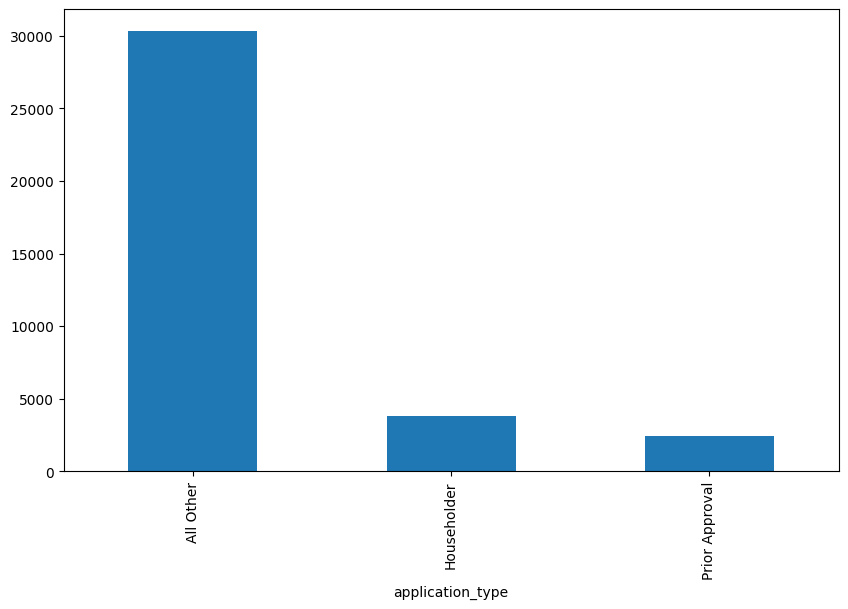

In [14]:
plt.figure(figsize=(10, 6))
planning_processed['application_type'].value_counts().plot(kind='bar')
print(planning_processed["application_type"].value_counts())

In [15]:
change_of_use = planning_processed[
    planning_processed['description'].str.contains(
        'change of use', case=False, na=False
    )
]
print(f"Applications mentioning 'change of use': {len(change_of_use)}")
print(change_of_use['description'].head(5))

Applications mentioning 'change of use': 1766
8     Certificate of lawfulness for proposed change ...
14    Prior approval for change of use of the ground...
33    Prior approval for change of use from retail t...
61     Change of use of Unit 18.01 from Class A1/A2/...
91    Prior approval for change of use from retail s...
Name: description, dtype: string


In [16]:
planning_processed['is_change_of_use'] = planning_processed['description'].str.contains(
    'change of use', case=False, na=False
)

### Finding: Change of Use Signal in Description Text
The `application_type` field does not contain a "Change of Use" category 
for our target boroughs. However, 1,766 applications (4.8% of valid records) 
explicitly mention "change of use" in their description text.

A binary feature `is_change_of_use` will be derived from description text 
during feature engineering rather than relying on the application_type field.

borough
Redbridge                   19382
London Borough of Newham     9886
Waltham Forest               7267
Newham                         16
Name: count, dtype: Int64


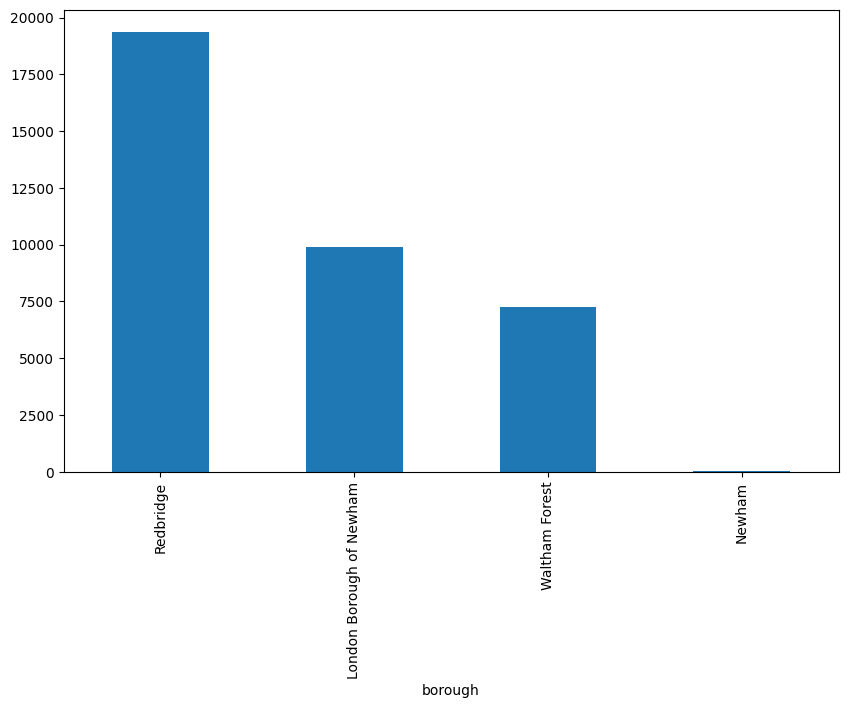

In [17]:
plt.figure(figsize=(10, 6))
planning_processed['borough'].value_counts().plot(kind='bar')
print(planning_processed["borough"].value_counts())

lpa_name
Redbridge         19384
Newham             9902
Waltham Forest     7267
Name: count, dtype: Int64


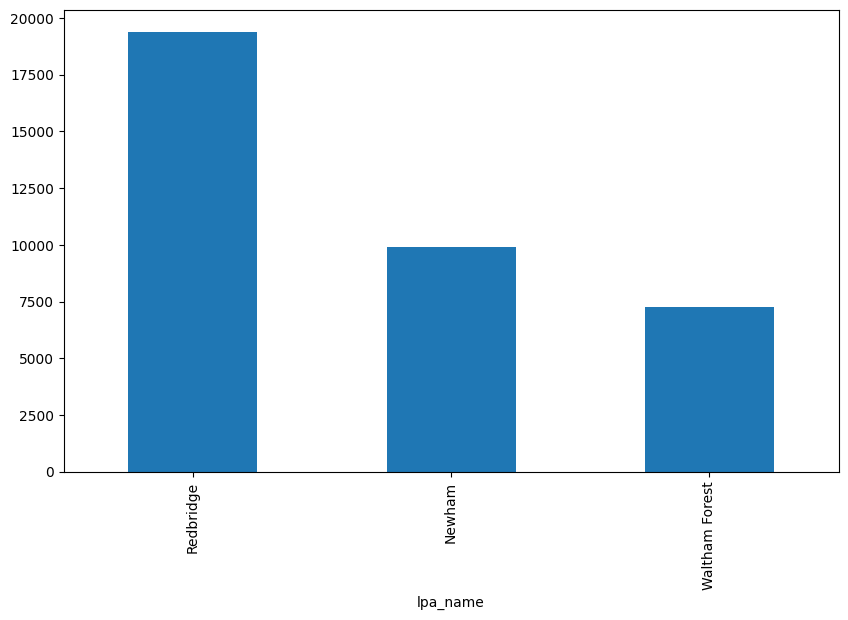

In [18]:
plt.figure(figsize=(10, 6))
planning_processed['lpa_name'].value_counts().plot(kind='bar')
print(planning_processed["lpa_name"].value_counts())

### Finding: Borough Column Inconsistency
The `borough` column contains inconsistent naming 
("London Borough of Newham" vs "Newham"). 
Use `lpa_name` for all borough-level aggregations â€” 
this field is consistently formatted as it's used 
directly in the API query.

In [19]:
print(planning_processed['valid_date'].head(5))

0    24/06/2024
1    21/07/2023
2    08/05/2021
3    29/03/2022
4    07/05/2024
Name: valid_date, dtype: string


In [20]:
planning_processed['valid_date'] = pd.to_datetime(planning_processed['valid_date'], format="%d/%m/%Y")
print(planning_processed['valid_date'].head(5))

0   2024-06-24
1   2023-07-21
2   2021-05-08
3   2022-03-29
4   2024-05-07
Name: valid_date, dtype: datetime64[ns]


Text(0, 0.5, 'Number of Applications')

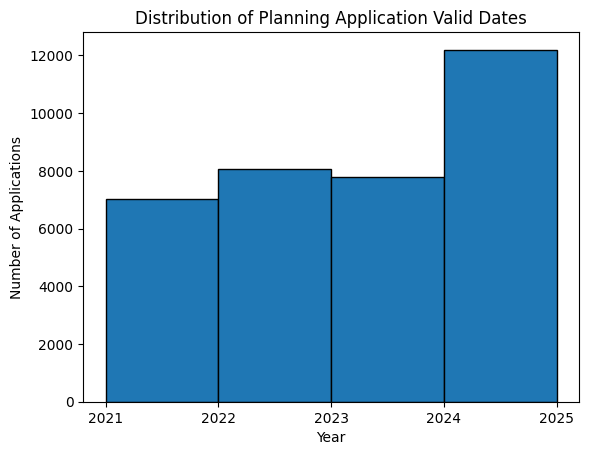

In [26]:
plt.hist(planning_processed['valid_date'].dt.year, bins=range(2021, 2026), edgecolor='black')
plt.xticks(range(2021, 2026))
plt.title('Distribution of Planning Application Valid Dates')
plt.xlabel("Year")
plt.ylabel('Number of Applications')

### Finding: Planning Activity Trend 2021-2024
Planning applications show an overall upward trend across the three 
boroughs, with a notable dip in 2023 (~7,800 vs ~8,000 in 2022) 
before a significant jump in 2024 (~12,000).

The 2023 dip is not explained by data lag â€” 2024-25 data is well 
represented. Possible explanations include the 2023 UK mortgage rate 
crisis suppressing development viability in outer East London, or 
borough-specific planning cycles. This warrants investigation when 
expanded to all 33 boroughs.

In [21]:
print(f"Unique H3 hexagons: {planning_processed['h3_index'].nunique()}")
print(f"Avg applications per hexagon: {len(planning_processed) / planning_processed['h3_index'].nunique():.1f}")

Unique H3 hexagons: 226
Avg applications per hexagon: 161.7


count    226.000000
mean     161.738938
std      128.217517
min        1.000000
25%       50.000000
50%      141.500000
75%      258.000000
max      558.000000
Name: count, dtype: float64


Text(0.5, 1.0, 'Distribution of Planning Applications per H3 Hexagon')

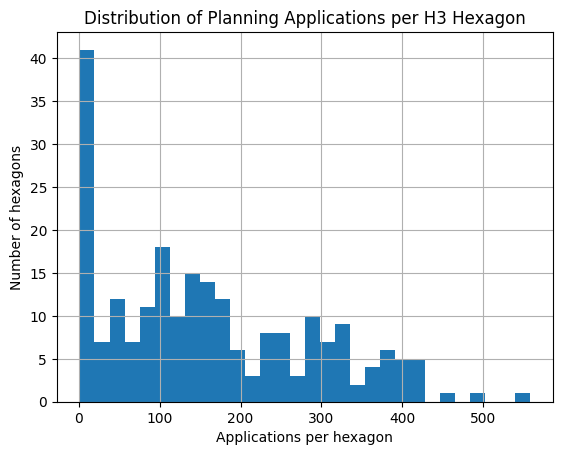

In [27]:
hex_counts = planning_processed['h3_index'].value_counts()
print(hex_counts.describe())
hex_counts.hist(bins=30)
plt.xlabel("Applications per hexagon")
plt.ylabel("Number of hexagons")
plt.title("Distribution of Planning Applications per H3 Hexagon")

### Finding: Skewed Application Distribution â€” Development Hotspots Exist
Planning applications are not evenly distributed across hexagons. 
The distribution is right-skewed (mean 161, median 141, max 558), 
indicating that a small number of hexagons account for 
disproportionate development activity. These high-activity hexagons 
are candidate gentrification hotspots â€” exactly what our model aims to identify.

In [28]:
top_hexagons = planning_processed['h3_index'].value_counts().head(20).index.tolist()
hotspots = planning_processed[planning_processed['h3_index'].isin(top_hexagons)]

m = folium.Map(location=[51.55, 0.05], zoom_start=11)

for _, row in hotspots.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True
    ).add_to(m)

m

### Finding: Development Hotspots Cluster Around Transport Corridors
The top 20 most active H3 hexagons reveal clear geographic clustering 
rather than random distribution. Notable concentrations appear around:

- **Walthamstow** â€” consistent with well-documented gentrification pressure 
  in this area
- **Redbridge/Ilford corridor** â€” high activity along the Elizabeth Line, 
  suggesting Crossrail-driven development pressure
- **Stratford/Upton Park** â€” post-Olympic legacy development continuing 
  to drive planning activity
- **Barking** â€” known regeneration zone showing significant activity

This spatial clustering confirms that planning activity is a 
geographically meaningful signal, not noise.

## 4. Coffee Shop Data Overview


In [29]:
print(coffee_processed.shape)
print(coffee_processed.dtypes)
coffee_processed.head()

(6689, 11)
geometry         geometry
name               object
brand              object
cuisine            object
opening_hours      object
start_date         object
addr:postcode      object
operator           object
latitude          float64
longitude         float64
h3_index           object
dtype: object


,geometry,name,brand,cuisine,opening_hours,start_date,addr:postcode,operator,latitude,longitude,h3_index
0,POINT (-0.33402 51.41101),None,None,None,None,None,None,ECSI Limited,51.411007,-0.334017,88194ad981fffff
1,POINT (-0.12925 51.52658),Woburn Cafe,None,None,None,None,None,None,51.526581,-0.129250,88195da4d1fffff
2,POINT (-0.11611 51.52476),Cafe Angel,None,None,None,None,None,None,51.524764,-0.116112,88195da4dbfffff
3,POINT (-0.07248 51.5509),Jack's Cafe,None,None,None,None,E8 2EZ,None,51.550905,-0.072478,88195da69bfffff
4,POINT (-0.05986 51.56915),Springfield Park Cafe,None,None,Mo-Su 10:00-18:00,None,E5 9EF,None,51.569151,-0.059863,88195da6dbfffff


In [34]:
# Create a mask for rows where the brand is missing (null)
independent_mask = coffee_processed['brand'].isna()

# Apply the mask and count the rows
independent_count = len(coffee_processed[independent_mask])

print(f"Independent coffee shops: {independent_count}")

Independent coffee shops: 5571


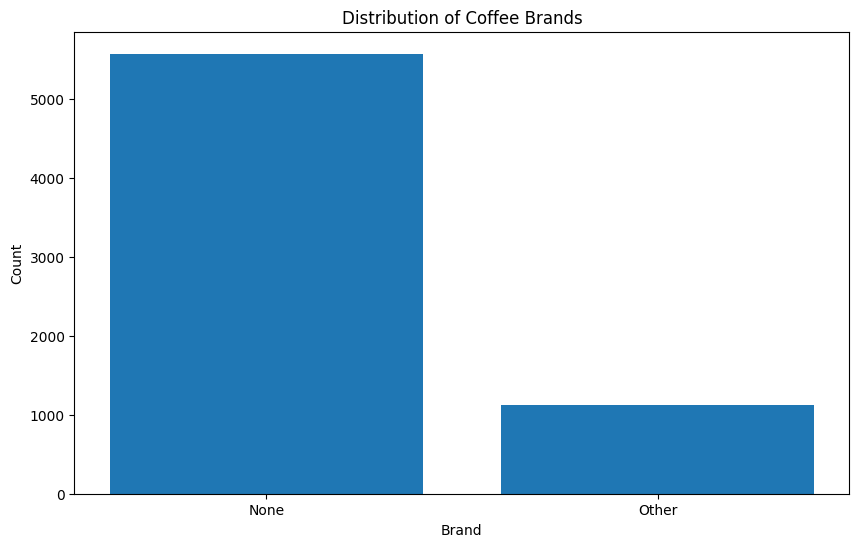

In [35]:
#Plot None vs other brands from brand column
none_brands = coffee_processed[coffee_processed['brand'].isna()]
other_brands = coffee_processed[coffee_processed['brand'].notna()]

plt.figure(figsize=(10, 6))
plt.bar(['None', 'Other'], [len(none_brands), len(other_brands)])
plt.xlabel('Brand')
plt.ylabel('Count')
plt.title('Distribution of Coffee Brands')
plt.show()



In [36]:
print(coffee_processed['brand'].value_counts().head(20))

brand
Costa                  317
Starbucks              214
CaffÃ¨ Nero             167
Joe & The Juice         49
Black Sheep Coffee      42
GAIL's Bakery           23
Blank Street Coffee     22
T4                      19
WatchHouse              12
Redemption Roasters     11
Notes                   11
Chaiiwala               10
Urban Baristas           9
Mooboo                   9
Colicci                  9
Wild Bean Cafe           8
Morrisons                8
Asda                     8
Harris + Hoole           8
CoCo                     7
Name: count, dtype: int64


note the 83% independent rate and why this matters for the hypothesis. Then paste the brand value counts and we'll decide how to classify chains vs independents before moving to the geographic distribution.

In [39]:
from src.config import CHAIN_BRANDS

coffee_processed['is_independent'] = ~coffee_processed['brand'].isin(CHAIN_BRANDS)
print(coffee_processed['is_independent'].value_counts())


is_independent
True     5890
False     799
Name: count, dtype: int64


Add a markdown finding:
Write it yourself â€” note the distinction between true chains and third-wave brands, explain why GAIL's and WatchHouse are actually gentrification signals, and state the final independent count.

In [44]:
from branca.element import Template, MacroElement # type: ignore
m = folium.Map(location=[51.55, 0.05], zoom_start=11)

# 2. Plot Planning Hotspots (Red)
for _, row in hotspots.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=7,
        color='red',
        fill=True,
        fill_opacity=0.4,
        tooltip="Planning Application"
    ).add_to(m)

# 3. Plot Independent Coffee Shops (Blue)
for _, row in coffee_processed[coffee_processed['is_independent'] == True].iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_opacity=0.7,
        tooltip=row.get('name', 'Independent Cafe')
    ).add_to(m)

# 4. Add the Floating Legend
legend_html = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 200px; height: 90px; 
    background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px;
    ">
    <b>Neighbourhood Pulse</b><br>
    <i class="fa fa-circle" style="color:red; opacity:0.5"></i> Planning Hotspots<br>
    <i class="fa fa-circle" style="color:blue; opacity:0.8"></i> Independent Cafes<br>
</div>
{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(legend_html)
m.get_root().add_child(macro)

import os
# Save the map to a physical file
m.save("london_pulse_map.html")

# This will automatically open the map in your default web browser (Chrome/Edge/Safari)
os.startfile("london_pulse_map.html")

## 5. Spatial Distribution


## 6. Key Findings


## 7. Discovering All Available Boroughs Before Scaling Ingestion

Ingestion currently targets three boroughs. Before scaling to all of Greater London, query the API's `lpa_name.raw` aggregation to discover the exact borough names (which must match the `term` filter verbatim) and their planning-application volumes. The `doc_count` per borough indicates relative planning activity and helps anticipate ingestion time and data volume.

In [ ]:
import requests

url = "https://planninglondondatahub.london.gov.uk/api-guest/applications/_search"
query = {
    "size": 0,
    "aggs": {
        "boroughs": {
            "terms": {"field": "lpa_name.raw", "size": 50}
        }
    }
}

response = requests.post(url, json=query)
buckets = response.json()["aggregations"]["boroughs"]["buckets"]

print(f"{len(buckets)} distinct lpa_name values:
")
for b in buckets:
    print(b["key"], "-", b["doc_count"])

### Finding: 33 Boroughs + 2 Development Corporations Available

The API exposes **35 distinct `lpa_name` values**: the 33 London boroughs plus two Mayoral Development Corporations â€” `LLDC` (London Legacy Development Corporation) and `OPDC` (Old Oak and Park Royal Development Corporation). The development corporations are **excluded** from `TARGET_BOROUGHS` as they are not boroughs.

Two takeaways for scaling ingestion:

1. **Exact naming matters.** The `term` filter on `lpa_name.raw` is an exact match, so several names deviate from their colloquial forms and must be copied verbatim: `Kensington & Chelsea`, `Hammersmith & Fulham`, `Barking & Dagenham` (ampersand, not "and"), and `Richmond`, `Kingston`, `Westminster` (no "upon Thames" / "City of"). A mismatch silently returns zero records.

2. **Volume is highly skewed.** Planning activity ranges from ~130k applications (Islington) down to ~11k (City of London). The three boroughs originally ingested (Newham, Redbridge, Waltham Forest) sit in the mid-to-lower range, so scaling to all 33 will increase total volume several-fold â€” Islington, Hounslow, and Ealing alone exceed the original three combined. Ingestion time and rate-limiting headroom should be planned accordingly.

In [4]:
import pandas as pd
import glob

planning = pd.read_parquet(r"C:\Users\Aniket\Documents\Projects\Neighbourhood_Pulse\data\raw\planning_applications.parquet")
print(f"Total records: {len(planning)}")
print(f"Boroughs present: {planning['lpa_name'].nunique()}")
print(planning['lpa_name'].value_counts())

files = glob.glob(r"C:\Users\Aniket\Documents\Projects\Neighbourhood_Pulse\data\raw\planning*.parquet")
print(f"\nPer-borough files saved: {len(files)}")

Total records: 531629
Boroughs present: 33
lpa_name
Westminster             39921
Barnet                  27558
Wandsworth              22493
Richmond                21371
Kensington & Chelsea    21132
Ealing                  21053
Croydon                 19989
Bromley                 19783
Redbridge               18886
Enfield                 18352
Lambeth                 17802
Southwark               17339
Hillingdon              16916
Hounslow                16253
Brent                   16009
Havering                14866
Kingston                14651
Islington               14565
Greenwich               14073
Hammersmith & Fulham    13800
Waltham Forest          13552
Lewisham                13352
Haringey                13114
Newham                  12744
Harrow                  12492
Hackney                 12425
Bexley                  12401
Sutton                  10914
Camden                  10909
Merton                   9936
Tower Hamlets            9862
Barking & Dagenham

In [7]:
planning = pd.read_parquet(r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/planning_processed.parquet")
print(f"Unique hexagons: {planning['h3_index'].nunique()}")
print(f"Avg applications per hexagon: {len(planning) / planning['h3_index'].nunique():.1f}")

Unique hexagons: 2568
Avg applications per hexagon: 191.3


In [6]:
import os
print(os.getcwd())

c:\Users\Aniket\Documents\Projects\Neighbourhood_Pulse\notebooks


In [11]:
import pandas as pd
df = pd.read_parquet(r'C:\Users\Aniket\Documents\Projects\Neighbourhood_Pulse\data\processed\planning_processed.parquet', columns=['h3_index','description'])
print('raw planning rows:', len(df))

df['is_change_of_use'] = df['description'].str.contains('change of use', case=False, na=False)

hex_planning = df.groupby('h3_index').agg(
    total_applications  = ('is_change_of_use', 'count'),
    change_of_use_count = ('is_change_of_use', 'sum'),
).reset_index()

print('hex_planning.shape:', hex_planning.shape)
print('change_of_use_count.sum():', int(hex_planning['change_of_use_count'].sum()))
print('raw is_change_of_use.sum():', int(df['is_change_of_use'].sum()))
print('lossless match:', int(hex_planning['change_of_use_count'].sum()) == int(df['is_change_of_use'].sum()))
print('total_applications.sum():', int(hex_planning['total_applications'].sum()), '== raw rows:', int(hex_planning['total_applications'].sum())==len(df))



raw planning rows: 491318
hex_planning.shape: (2568, 3)
change_of_use_count.sum(): 19893
raw is_change_of_use.sum(): 19893
lossless match: True
total_applications.sum(): 491318 == raw rows: True


### Temporal features â€” recency and velocity

Temporal signal separates "this area is active" from "this area is *accelerating*".

- **`applications_recent`** â€” applications in the most recent 12 months.
- **`planning_velocity`** â€” `applications_recent / (total_applications / span_years)`.
  Above 1 = more active recently than its own historical average (accelerating);
  below 1 = cooling.

Two design decisions:

1. `valid_date` is parsed with an explicit day-first `format='%d/%m/%Y'` (pandas
   would otherwise guess and silently mangle ambiguous dates like `03/04/2023`),
   and `errors='coerce'` so unparseable dates become `NaT` and are dropped.
2. "Last 12 months" is anchored to **`max(valid_date)`**, not `today()`. This
   makes features a function of the *data* not the *run date* (reproducible:
   same data -> same features), and avoids the reporting-lag bias that anchoring
   to today would introduce (the window's trailing edge would sit in the
   under-populated zone, biasing velocity below 1 for every hexagon).


In [2]:
import pandas as pd
from src.config import PLANNING_PROCESSED_PATH

# Reload with valid_date (the prior cell only needed h3_index + description).
planning_df = pd.read_parquet(PLANNING_PROCESSED_PATH, columns=["h3_index", "valid_date"])

# 1. Parse dates (day-first), drop the unplaceable ones.
planning_df["valid_date"] = pd.to_datetime(
    planning_df["valid_date"], format="%d/%m/%Y", errors="coerce"
)
print("unparseable dates dropped:", int(planning_df["valid_date"].isna().sum()))
planning_df = planning_df.dropna(subset=["valid_date"])

# 2. Anchor to the dataset's latest date (reproducible + lag-robust).
anchor = planning_df["valid_date"].max()
recent_cutoff = anchor - pd.DateOffset(months=12)
span_years = (anchor - planning_df["valid_date"].min()).days / 365.25
print(f"anchor={anchor.date()}  recent_cutoff={recent_cutoff.date()}  span_years={span_years:.2f}")

# 3. Recent count per hexagon.
planning_df["is_recent"] = planning_df["valid_date"] >= recent_cutoff
recent = (planning_df.groupby("h3_index")["is_recent"].sum()
          .rename("applications_recent").reset_index())

# 4. Merge onto hex_planning, then derive velocity.
hex_planning = hex_planning.merge(recent, on="h3_index", how="left")
hex_planning["applications_recent"] = hex_planning["applications_recent"].fillna(0).astype(int)
avg_annual = hex_planning["total_applications"] / span_years
hex_planning["planning_velocity"] = hex_planning["applications_recent"] / avg_annual

# --- sanity checks ---
print(hex_planning[["applications_recent", "planning_velocity"]].describe())


unparseable dates dropped: 0
anchor=2026-05-30  recent_cutoff=2025-05-30  span_years=5.00
       applications_recent  planning_velocity
count          2568.000000             2568.0
mean             30.278037           0.694652
std              44.833829           0.526247
min               0.000000                0.0
25%               3.000000           0.430812
50%              19.500000           0.719203
75%              40.000000           0.918401
max             761.000000           4.999316


### Diagnostic: monthly application trend â€” is sub-1 velocity lag or real cooling?

The initial temporal features gave a mean `planning_velocity` of 0.69 (< 1), implying the
recent year runs below the historical average. Before trusting that, check whether the
recent months are genuinely quieter or just **under-reported** (ingestion lag). Plot
monthly counts: a **cliff** in the final 1-3 months = lag; a **stable plateau** to the
edge = real slowdown.

median monthly applications: 8118
last 6 months (valid_date month -> count):
  2025-12  6421
  2026-01  6304
  2026-02  6475
  2026-03  7199
  2026-04  4899
  2026-05  1318


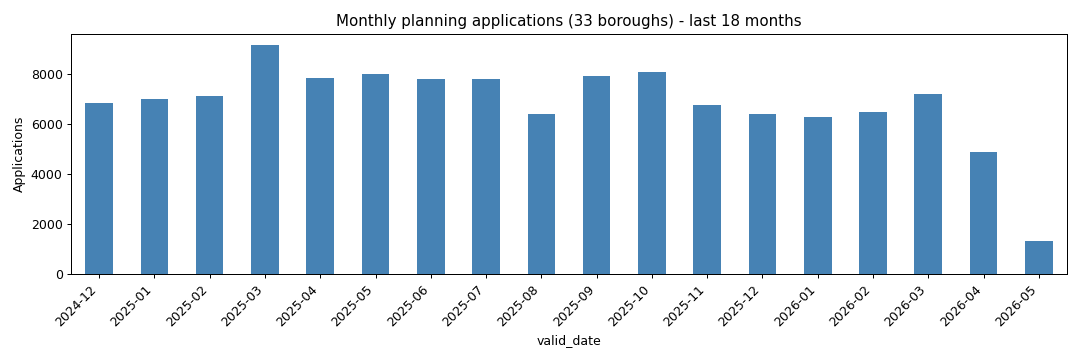

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

PROCESSED = r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/planning_processed.parquet"
planning_df = pd.read_parquet(PROCESSED, columns=["valid_date"])
planning_df["valid_date"] = pd.to_datetime(planning_df["valid_date"], format="%d/%m/%Y", errors="coerce")
planning_df = planning_df.dropna(subset=["valid_date"])

monthly = planning_df.set_index("valid_date").resample("ME").size()
print(f"median monthly applications: {monthly.median():.0f}")
print("last 6 months (valid_date month -> count):")
for ts, n in monthly.tail(6).items():
    print(f"  {ts:%Y-%m}  {n}")

ax = monthly.tail(18).plot(kind="bar", figsize=(12, 4), color="steelblue")
ax.set_title("Monthly planning applications (33 boroughs) - last 18 months")
ax.set_ylabel("Applications")
ax.set_xticklabels([t.get_text()[:7] for t in ax.get_xticklabels()], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/notebooks/images/monthly_trend.png", dpi=90)
plt.show()


### Measuring the lag directly â€” and discovering what the fields actually are

The count cliff *infers* lag; we tried to *measure* it. Sampled one high-volume borough
(Islington, full 5y range) with `last_updated` / `last_synced` added to the ingestion query
(`data/raw/lag_sample_islington.parquet`). A field-semantics check first revealed a **bulk
re-sync (~Mar-Apr 2025)** that overwrote original timestamps for all older records â€” so the
full-sample delta (p50 ~646d) is contaminated and only post-resync cohorts are usable.

**Finding 1 â€” the timestamps are `last-touch`, not `first-appearance`, so they cannot measure
ingestion lag.** In the exhibit below, median `last_synced âˆ’ valid_date` *shrinks*
monotonically for more recent valid-month cohorts (Apr-2025: 225d â†’ Feb-2026: 51d â†’ May-2026:
5d), while the *present record count per month stays flat* (~215-310). If the delta were true
appearance lag, recent months would be missing most of their records (far lower counts) â€” they
aren't. The delta grows with a record's **age** because these fields log the *most recent*
touch, accumulating re-syncs over a record's life. So the "~1 day" delta on the newest records
is a trap (newly touched â‰  promptly appeared). The records we'd need to measure recent-month
lag â€” the ones still to arrive â€” are **structurally absent** (survivorship), and no
`created`/`first-seen` field is exposed. (Decided vs undecided medians match at 120/133d, so
it isn't decision bumps either.)

**Finding 2 â€” lag is borough-specific.** Islington's monthly counts are flat to the recent
edge: **no** April/May cliff. So the *aggregate* cliff (Apr 66%, May 18%) is driven by *other*
boroughs with slower/burstier sync â€” the per-LPA variation anticipated when choosing the sample.

**Consequences.** (1) The direct measurement can't confirm the lag magnitude; the **aggregate
count-cliff stays the primary evidence** for the trim, which still stands. (2) Because lag is
borough-specific, an *aggregate* trim is crude â€” it would wrongly trim Islington's healthy recent
data along with the laggy boroughs'. The correct refinement is a **per-borough trim** (apply the
contiguous-trailing rule to each borough's own monthly series). (3) A clean lag measurement would
need a record-level `created` timestamp the API does not expose.

In [2]:
import pandas as pd

LAG = r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw/lag_sample_islington.parquet"
lag = pd.read_parquet(LAG)

vd = pd.to_datetime(lag["valid_date"], format="%d/%m/%Y", errors="coerce")
lu = pd.to_datetime(lag["last_updated"], errors="coerce", utc=True).dt.tz_localize(None)
ls = pd.to_datetime(lag["last_synced"], errors="coerce", utc=True).dt.tz_localize(None)
day = 86400.0
d_synced = (ls - vd).dt.total_seconds() / day
diff = (ls - lu).dt.total_seconds() / day
decided = lag["decision"].notna()

print(f"records: {len(lag)}   decided fraction: {decided.mean():.0%}")
print(f"last_synced - last_updated (days): p50={diff.quantile(.5):.1f}  p95={diff.quantile(.95):.1f}"
      f"  -> coupled 'last-touch' stamps")

cal = (vd >= "2025-06-01") & (vd <= "2025-09-30")
print(f"Jun-Sep 2025 median d_synced: decided={d_synced[cal & decided].median():.0f}d  "
      f"undecided={d_synced[cal & ~decided].median():.0f}d  -> similar, not decision-driven")

print("\nKEY EXHIBIT: median (last_synced - valid_date) vs present count, by valid-month")
clean = pd.DataFrame({"vd": vd, "d": d_synced}).dropna()
med = clean.set_index("vd").resample("ME")["d"].median()
cnt = clean.set_index("vd").resample("ME").size()
print(f"  {'month':<9}{'present':>9}{'median_d':>11}")
for ts in med.index:
    if ts >= pd.Timestamp("2025-04-30"):
        print(f"  {ts:%Y-%m}{int(cnt[ts]):>9}{med[ts]:>11.0f}")
print("\n=> delta shrinks for recent cohorts while counts stay flat")
print("   => last-touch timestamp, NOT appearance lag; Islington shows no aggregate-style cliff.")


records: 14565   decided fraction: 85%
last_synced - last_updated (days): p50=19.3  p95=96.4  -> coupled 'last-touch' stamps
Jun-Sep 2025 median d_synced: decided=120d  undecided=133d  -> similar, not decision-driven

KEY EXHIBIT: median (last_synced - valid_date) vs present count, by valid-month
  month      present   median_d
  2025-04      231        225
  2025-05      228        189
  2025-06      235        162
  2025-07      221        127
  2025-08      246         96
  2025-09      272         76
  2025-10      311         71
  2025-11      236         71
  2025-12      254         58
  2026-01      220         56
  2026-02      287         51
  2026-03      241         42
  2026-04      215          9
  2026-05       55          5

=> delta shrinks for recent cohorts while counts stay flat
   => last-touch timestamp, NOT appearance lag; Islington shows no aggregate-style cliff.


### Reporting-lag trim + feature rebuild (canonical, trimmed frame)

The monthly-trend diagnostic showed a clean cliff (Mar normal -> Apr 66% -> May 18%):
reporting lag, ~2 months deep. The trailing window is under-reported, which was
deflating `applications_recent` and biasing `planning_velocity` below 1.

Fix â€” applied **upstream, once, before any groupby**, so every feature is computed
on one internally-consistent frame:

1. Resample to monthly counts; `threshold = LAG_TRIM_FRACTION * median`.
2. Walk **backwards from the most recent month**, trimming while `count < threshold`,
   stopping at the first complete month. Lag is monotonic from the trailing edge,
   so only a **contiguous tail** is removed â€” interior dips are real signal, kept.
3. **Cap** the trim at `MAX_LAG_MONTHS`; a longer run is implausible as lag and is
   *flagged*, not silently deleted â€” the ambiguous case becomes a visible decision.
4. Anchor = end of last complete month; drop records after it. Temporal features
   anchor here (not `today()`), so they stay reproducible *and* lag-corrected.

Expectation: with the artifact removed, mean velocity should recenter toward ~1.


In [3]:
import pandas as pd
from src.config import PLANNING_PROCESSED_PATH, LAG_TRIM_FRACTION, MAX_LAG_MONTHS

# Per-application processed frame (full, untrimmed).
planning_df = pd.read_parquet(
    PLANNING_PROCESSED_PATH, columns=["h3_index", "description", "valid_date"]
)
planning_df["valid_date"] = pd.to_datetime(
    planning_df["valid_date"], format="%d/%m/%Y", errors="coerce"
)
planning_df = planning_df.dropna(subset=["valid_date"])

# --- Upstream reporting-lag trim (defines the dataset boundary for ALL features) ---
monthly = planning_df.set_index("valid_date").resample("ME").size()
threshold = LAG_TRIM_FRACTION * monthly.median()

# Contiguous trailing run below threshold (lag is monotonic from the edge).
below = 0
for count in reversed(monthly.values):
    if count < threshold:
        below += 1
    else:
        break

if below > MAX_LAG_MONTHS:
    print(f"WARNING: {below} trailing months below threshold (> MAX_LAG_MONTHS="
          f"{MAX_LAG_MONTHS}) -- exceeds plausible lag depth, may be a real decline. "
          f"Capping trim at {MAX_LAG_MONTHS}; investigate.")
trim_n = min(below, MAX_LAG_MONTHS)
anchor = monthly.index[-(trim_n + 1)]

n_before = len(planning_df)
planning_df = planning_df[planning_df["valid_date"] <= anchor]
dropped = n_before - len(planning_df)
print(f"median monthly={monthly.median():.0f}  threshold={threshold:.0f}  "
      f"months trimmed={trim_n}  anchor={anchor.date()}")
print(f"records dropped by trim: {dropped} ({dropped / n_before:.1%})")

# --- Volume features ---
planning_df["is_change_of_use"] = planning_df["description"].str.contains(
    "change of use", case=False, na=False
)
hex_planning = planning_df.groupby("h3_index").agg(
    total_applications=("is_change_of_use", "count"),
    change_of_use_count=("is_change_of_use", "sum"),
).reset_index()
hex_planning["change_of_use_ratio"] = (
    hex_planning["change_of_use_count"] / hex_planning["total_applications"]
)

# --- Temporal features (anchored to the trimmed boundary) ---
recent_cutoff = anchor - pd.DateOffset(months=12)
span_years = (anchor - planning_df["valid_date"].min()).days / 365.25
planning_df["is_recent"] = planning_df["valid_date"] > recent_cutoff
recent = (planning_df.groupby("h3_index")["is_recent"].sum()
          .rename("applications_recent").reset_index())
hex_planning = hex_planning.merge(recent, on="h3_index", how="left")
hex_planning["applications_recent"] = hex_planning["applications_recent"].fillna(0).astype(int)
hex_planning["planning_velocity"] = (
    hex_planning["applications_recent"] / (hex_planning["total_applications"] / span_years)
)

print(f"recent_cutoff={recent_cutoff.date()}  span_years={span_years:.2f}")
print(f"hex_planning.shape: {hex_planning.shape}")
print(hex_planning[["applications_recent", "planning_velocity"]].describe())


median monthly=8118  threshold=6088  months trimmed=2  anchor=2026-03-31
records dropped by trim: 6217 (1.3%)
recent_cutoff=2025-03-31  span_years=4.84
hex_planning.shape: (2568, 6)
       applications_recent  planning_velocity
count          2568.000000             2568.0
mean             33.892134           0.777215
std              48.421049           0.531545
min               0.000000                0.0
25%               5.000000           0.521392
50%              22.000000           0.790114
75%              45.000000           1.007397
max             811.000000           4.835044


### Cross-border hexagons â€” does the per-borough trim need a tie-break rule?

Per-borough trimming gives each borough its own anchor, so a hexagon that straddles a
borough boundary (res-8 ~0.7 km^2) is ambiguous: which borough's frame governs it? First
**measure** how common that is before picking a rule.

In [1]:
import pandas as pd
PROCESSED = r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/planning_processed.parquet"
df = pd.read_parquet(PROCESSED, columns=["h3_index", "lpa_name"]).dropna(subset=["h3_index"])

counts = df.groupby(["h3_index", "lpa_name"]).size()
total = counts.groupby("h3_index").sum()
modal = counts.groupby("h3_index").max()
n_boroughs = counts.groupby("h3_index").size()
modal_share = modal / total

print(f"hexagons: {len(total)}   single-borough: {(n_boroughs==1).mean():.1%}")
for thr in (0.99, 0.95, 0.90, 0.60):
    print(f"  modal_share >= {thr:.2f}: {(modal_share>=thr).mean():.1%}")
print(f"genuinely split (<0.60): {(modal_share<0.60).mean():.1%}")
print(f"minority-side records (leak surface): {(total-modal).sum()/total.sum():.2%} of all records")


hexagons: 2568   single-borough: 79.9%
  modal_share >= 0.99: 82.2%
  modal_share >= 0.95: 86.3%
  modal_share >= 0.90: 88.9%
  modal_share >= 0.60: 97.1%
genuinely split (<0.60): 2.9%
minority-side records (leak surface): 5.27% of all records


### Per-borough trim (single-frame rule) + per-borough `span_b` velocity

The lag measurement showed lag is **borough-specific** â€” an aggregate trim wrongly penalises
prompt boroughs (Islington) and under-trims laggy ones. Fix: trim each borough by its **own**
monthly series (contiguous-trailing rule, capped at `MAX_LAG_MONTHS`), giving each borough its
own `anchor_b` and covered `span_b`.

**`span_b` is per-borough** because `avg_annual = total / span` is only a true per-year rate if
`span` equals the time that borough's (trimmed) data covers. A global span would divide a
laggy borough's `total` by months it has no data for -> inflated velocity -> the very
fake-acceleration artifact we removed. Velocity stays comparable across boroughs because it is a
ratio of two annualised rates *within the same borough's frame* (we trade calendar-alignment of
the recent windows for lag-cleanliness â€” the right trade for a slow-moving signal).

**Cross-border rule (single-frame):** ~20% of hexagons straddle boroughs (5% of records on the
minority side), so the tie-break matters. Each hexagon is assigned to its **dominant (modal)
borough**, whose frame governs *everything* â€” anchor, span, recent-window, and the hexagon's own
record trim. This leaks only a few minority-borough records (no rate distortion), vs a
dominant-span rule which would re-introduce velocity inflation (a biased denominator). Caveat:
74 hexagons (2.9%) are genuinely split <60%, where 'dominant' is weak â€” documented.

**Known limitation (flagged, not resolved):** the `MAX_LAG_MONTHS` cap fired on Waltham
Forest (7-month trailing run) and Merton (6 months). Beyond 4 months a decline is too long
to be plausibly pure ingestion lag, so the cap trims 4 and keeps the rest â€” but whether that
residual is *real cooling* or *deeper lag* is left undecided (a monthly cliff-vs-slope check
would disambiguate; deferred as low-value). For a gentrification signal, genuine cooling is
itself information, so retaining it is the safe default. (Callback: this means Waltham Forest
â€” one of the original 3 EDA boroughs â€” may be genuinely cooling, which recontextualises the
earlier '2023 dip' discussion for that borough specifically.)

In [2]:
import pandas as pd
from src.config import LAG_TRIM_FRACTION, MAX_LAG_MONTHS

PROCESSED = r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/planning_processed.parquet"
df = pd.read_parquet(PROCESSED, columns=["h3_index", "lpa_name", "description", "valid_date"])
df["valid_date"] = pd.to_datetime(df["valid_date"], format="%d/%m/%Y", errors="coerce")
df = df.dropna(subset=["valid_date", "h3_index"])

# Each hexagon -> its dominant (modal) borough.
hex_borough = df.groupby("h3_index")["lpa_name"].agg(lambda s: s.value_counts().idxmax())

# Per-borough contiguous-trailing-trim anchor + covered span, from each borough's OWN series.
anchor_b, span_b, trim_n_b, capped = {}, {}, {}, []
for b, sub in df.groupby("lpa_name"):
    monthly = sub.set_index("valid_date").resample("ME").size()
    threshold = LAG_TRIM_FRACTION * monthly.median()
    below = 0
    for c in reversed(monthly.values):
        if c < threshold:
            below += 1
        else:
            break
    if below > MAX_LAG_MONTHS:
        capped.append((b, below))
    trim_n = min(below, MAX_LAG_MONTHS)
    a = monthly.index[-(trim_n + 1)]
    anchor_b[b], trim_n_b[b] = a, trim_n
    span_b[b] = (a - sub["valid_date"].min()).days / 365.25

if capped:
    print("CAPPED boroughs (trailing run > MAX_LAG_MONTHS -> likely real decline, not lag):")
    for b, below in capped:
        print(f"  {b}: {below} months")

# Single-frame: governing frame for each record = its hexagon's dominant borough.
df["gov_borough"] = df["h3_index"].map(hex_borough)
df["gov_anchor"] = df["gov_borough"].map(anchor_b)
df["gov_cutoff"] = df["gov_anchor"] - pd.DateOffset(months=12)

before = len(df)
df = df[df["valid_date"] <= df["gov_anchor"]]
print(f"per-borough trim dropped {before-len(df)} records ({(before-len(df))/before:.1%}) "
      f"vs aggregate trim's 1.3%")

df["is_change_of_use"] = df["description"].str.contains("change of use", case=False, na=False)
df["is_recent"] = df["valid_date"] > df["gov_cutoff"]
hexf = df.groupby("h3_index").agg(
    total_applications=("is_change_of_use", "count"),
    change_of_use_count=("is_change_of_use", "sum"),
    applications_recent=("is_recent", "sum"),
).reset_index()
hexf["change_of_use_ratio"] = hexf["change_of_use_count"] / hexf["total_applications"]
hexf["borough"] = hexf["h3_index"].map(hex_borough)
hexf["span_years"] = hexf["borough"].map(span_b)
hexf["planning_velocity"] = hexf["applications_recent"] / (hexf["total_applications"] / hexf["span_years"])

print(f"\nhex feature matrix: {hexf.shape}")
print("\noverall planning_velocity (per-borough trim):")
print(hexf["planning_velocity"].describe(percentiles=[.25,.5,.75]).round(3))

rep = hexf.groupby("borough").agg(n_hex=("h3_index", "size"),
                                  mean_velocity=("planning_velocity", "mean"))
rep["trim_n"] = rep.index.map(trim_n_b)
rep["span_yrs"] = rep.index.map(span_b).round(2)
print("\nmost-trimmed boroughs (laggiest) vs least:")
rep = rep.sort_values("trim_n", ascending=False)
print(rep.head(6).round(3))
print("...")
print(rep.tail(4).round(3))


CAPPED boroughs (trailing run > MAX_LAG_MONTHS -> likely real decline, not lag):
  Merton: 6 months
  Waltham Forest: 7 months
per-borough trim dropped 3322 records (0.7%) vs aggregate trim's 1.3%

hex feature matrix: (2567, 8)

overall planning_velocity (per-borough trim):
count    2567.0
mean      0.833
std       0.516
min         0.0
25%       0.627
50%       0.835
75%       1.032
max       4.914
Name: planning_velocity, dtype: Float64

most-trimmed boroughs (laggiest) vs least:
                      n_hex  mean_velocity  trim_n  span_yrs
borough                                                     
Waltham Forest           59          0.632       4      4.67
Merton                   49          0.874       4      4.67
Lewisham                 56           0.79       3      4.50
Lambeth                  43          0.813       2      4.84
Bromley                 220          0.896       2      4.00
Hammersmith & Fulham     25          0.979       2      4.67
...
               n_hex 

### Coffee features + left-merge â€” completing the hexagon feature matrix

Aggregate cafes to hexagon level and **left-join onto the planning matrix** (planning hexagons
are the unit of analysis; cafes *enrich* them â€” the join decision we settled earlier). A cafe
is **independent** if its `brand` is not in `CHAIN_BRANDS` â€” and a null brand counts as
independent, since OSM rarely tags independents. `total_cafe_count` = all cafes,
`independent_cafe_count` = non-chain. After the left join, `fillna(0)` so a planning hexagon
with no cafes reads 0 (not NaN). `cafe_to_application_ratio = total_cafe_count /
total_applications` is divide-by-zero-safe â€” every hexagon has >=1 application by construction.
Saves the full matrix to `data/processed/hex_features.parquet` for the modelling step.

In [1]:
import pandas as pd
from src.config import COFFEE_SHOPS_PROCESSED_PATH, CHAIN_BRANDS

COFFEE = r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/coffee_shops_processed.parquet"
coffee = pd.read_parquet(COFFEE, columns=["h3_index", "brand"]).dropna(subset=["h3_index"])

# Independent = brand not a known chain (a null brand is independent).
coffee["is_independent"] = ~coffee["brand"].isin(CHAIN_BRANDS)
hex_coffee = coffee.groupby("h3_index").agg(
    total_cafe_count=("is_independent", "size"),
    independent_cafe_count=("is_independent", "sum"),
).reset_index()

# Left-merge onto the planning matrix; planning hexagons stay the unit.
hexf = hexf.merge(hex_coffee, on="h3_index", how="left")
for col in ["total_cafe_count", "independent_cafe_count"]:
    hexf[col] = hexf[col].fillna(0).astype(int)
hexf["cafe_to_application_ratio"] = hexf["total_cafe_count"] / hexf["total_applications"]

OUT = r"C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/hex_features.parquet"
hexf.to_parquet(OUT, index=False)

print("feature matrix:", hexf.shape)
print("columns:", list(hexf.columns))
nc = (hexf["total_cafe_count"] > 0).sum()
print(f"\nhexagons with >=1 cafe: {nc} ({nc/len(hexf):.1%})")
tot = int(hexf["total_cafe_count"].sum())
ind = int(hexf["independent_cafe_count"].sum())
print(f"total cafes mapped: {tot}   independent: {ind} ({ind/max(tot,1):.1%})")
print("\ncafe + ratio columns describe:")
print(hexf[["total_cafe_count", "independent_cafe_count", "cafe_to_application_ratio"]]
      .describe(percentiles=[.5, .9, .99]).round(3))
print("\nsaved feature matrix ->", OUT)


feature matrix: (2567, 11)
columns: ['h3_index', 'total_applications', 'change_of_use_count', 'applications_recent', 'change_of_use_ratio', 'borough', 'span_years', 'planning_velocity', 'total_cafe_count', 'independent_cafe_count', 'cafe_to_application_ratio']

hexagons with >=1 cafe: 1167 (45.5%)
total cafes mapped: 6678   independent: 5886 (88.1%)

cafe + ratio columns describe:
       total_cafe_count  independent_cafe_count  cafe_to_application_ratio
count          2567.000                2567.000                     2567.0
mean              2.601                   2.293                      0.014
std               6.726                   5.783                      0.078
min               0.000                   0.000                        0.0
50%               0.000                   0.000                        0.0
90%               7.000                   6.000                      0.029
99%              32.340                  28.000                      0.134
max             

## 9. Land Registry target â€” data exploration

The model needs a ground-truth target: per-hexagon price growth. Land Registry Price Paid Data
(`pp-2021..2025.csv`, national) is the source. First, understand its structure, gauge its size,
and confirm we can subset to London cheaply (by **district** = local authority) before building
the target.

Standard 16-column PPD layout (no header): `0` id, `1` price, `2` date of transfer, `3` postcode,
`4` property type (D/S/T/F/O), `5` old/new, `6` duration, `7-13` address fields incl. `12` district
(local authority), `14` county, `15` PPD category (A = standard, B = repossessions/bulk).
**No coordinates** â€” so mapping sales to H3 hexagons needs a postcode bridge (resolved in the
target-build step).

In [1]:
import os
import pandas as pd
from src.config import TARGET_BOROUGHS

RAW = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw"

# --- Raw structure: all 16 columns, first rows ---
raw = pd.read_csv(f"{RAW}/pp-2021.csv", header=None, nrows=3)
print("columns:", raw.shape[1])
print(raw.to_string())

# --- File sizes per year (national) ---
print("\nfile sizes (national):")
for y in [2021, 2022, 2023, 2024, 2025]:
    mb = os.path.getsize(f"{RAW}/pp-{y}.csv") / 1e6
    print(f"  pp-{y}.csv: {mb:.1f} MB")

# --- London subset via district (local authority) ---
usecols = {1: "price", 2: "date", 3: "postcode", 4: "ptype", 12: "district", 15: "category"}
sample = pd.read_csv(f"{RAW}/pp-2025.csv", header=None, usecols=list(usecols), names=list(usecols.values()))
print("\nnational rows (2025):", len(sample))

# LR spells a few boroughs in full; map our config names -> LR district names.
NAME_FIX = {"KINGSTON": "KINGSTON UPON THAMES", "RICHMOND": "RICHMOND UPON THAMES",
            "WESTMINSTER": "CITY OF WESTMINSTER"}
london_districts = {NAME_FIX.get(b.upper().replace("&", "AND"), b.upper().replace("&", "AND"))
                    for b in TARGET_BOROUGHS}

ld = sample[sample["district"].isin(london_districts)]
print(f"London rows (2025): {len(ld)} ({len(ld)/len(sample):.1%})  | boroughs matched: {ld['district'].nunique()}/33")
print("boroughs not found (should be empty after NAME_FIX):", london_districts - set(sample["district"].unique()))

print("\nproperty-type mix (London 2025):", ld["ptype"].value_counts().to_dict())
print("category mix:", ld["category"].value_counts().to_dict())
print("\nsample London sales:")
print(ld[["price", "date", "postcode", "ptype", "district"]].head(4).to_string(index=False))


columns: 16
                                       0       1                 2         3  4  5  6   7   8              9            10              11             12     13 14 15
0  {D22473F5-3802-7B40-E053-6C04A8C0A630}  230000  2021-06-09 00:00  CO13 0PQ  D  N  F   4 NaN  BELLAMY CLOSE  KIRBY CROSS  FRINTON-ON-SEA       TENDRING  ESSEX  A  A
1  {D22473F5-3803-7B40-E053-6C04A8C0A630}  700000  2021-06-25 00:00  IG10 4BS  T  N  F  70 NaN    SMARTS LANE          NaN        LOUGHTON  EPPING FOREST  ESSEX  A  A
2  {D22473F5-3804-7B40-E053-6C04A8C0A630}  625000  2021-06-28 00:00   EN9 1LH  S  N  F   7 NaN    THE COBBINS          NaN   WALTHAM ABBEY  EPPING FOREST  ESSEX  A  A

file sizes (national):
  pp-2021.csv: 223.2 MB
  pp-2022.csv: 187.7 MB
  pp-2023.csv: 150.1 MB
  pp-2024.csv: 161.5 MB
  pp-2025.csv: 147.9 MB

national rows (2025): 849880
London rows (2025): 93481 (11.0%)  | boroughs matched: 33/33
boroughs not found (should be empty after NAME_FIX): set()

property-type mix (London

## 10. Target feasibility â€” survival diagnostic (run before building the target)

The target is median price growth in single-year windows at hexagon resolution, but residential
sales are sparse. Before committing to the `2023 vs 2024-25` split, **measure how many hexagons
survive a min-sales threshold in BOTH windows and still carry planning signal** â€” that count
decides whether the split is viable or the windows must widen.

Mapping note: this uses a `postcode -> h3` lookup built from planning + coffee records (both carry
`postcode <-> h3_index`), so LR sales at postcodes absent from our data are unmapped â€” the survival
count is therefore a **lower bound** (full geocoding would only raise it). Coverage is reported.

In [1]:
import re
import pandas as pd
from src.config import TARGET_BOROUGHS

RAW = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw"
PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"

def norm_pc(s):
    return s.astype("string").str.upper().str.replace(r"\s+", "", regex=True)

# 1. postcode -> h3 lookup from planning + coffee (modal h3 per postcode).
pl = pd.read_parquet(f"{PROC}/planning_processed.parquet", columns=["postcode", "h3_index"]).dropna()
pl["pc"] = norm_pc(pl["postcode"])
cof = pd.read_parquet(f"{PROC}/coffee_shops_processed.parquet", columns=["addr:postcode", "h3_index"]).dropna()
cof = cof.rename(columns={"addr:postcode": "postcode"})
cof["pc"] = norm_pc(cof["postcode"])
both = pd.concat([pl[["pc", "h3_index"]], cof[["pc", "h3_index"]]], ignore_index=True)
pc2h3 = both.groupby("pc")["h3_index"].agg(lambda s: s.value_counts().idxmax())
print(f"postcode->h3 lookup: {len(pc2h3)} postcodes")

# 2. Load LR London residential category-A sales for the target years.
NAME_FIX = {"KINGSTON": "KINGSTON UPON THAMES", "RICHMOND": "RICHMOND UPON THAMES",
            "WESTMINSTER": "CITY OF WESTMINSTER"}
london = {NAME_FIX.get(b.upper().replace("&", "AND"), b.upper().replace("&", "AND")) for b in TARGET_BOROUGHS}
cols = {1: "price", 2: "date", 3: "postcode", 4: "ptype", 12: "district", 15: "category"}

def load(year):
    df = pd.read_csv(f"{RAW}/pp-{year}.csv", header=None, usecols=list(cols), names=list(cols.values()))
    df = df[df["district"].isin(london) & df["ptype"].isin(["D", "S", "T", "F"]) & (df["category"] == "A")].copy()
    df["year"] = pd.to_datetime(df["date"]).dt.year
    return df

lr = pd.concat([load(y) for y in (2023, 2024, 2025)], ignore_index=True)
lr["pc"] = norm_pc(lr["postcode"])
lr["h3"] = lr["pc"].map(pc2h3)
cov = lr["h3"].notna().mean()
print(f"LR London residential sales (2023-25): {len(lr)}   mapped to a hexagon: {cov:.1%} (lower-bound count)")

mapped = lr.dropna(subset=["h3"])
n_base = mapped[mapped.year == 2023].groupby("h3").size().rename("n_base")
n_out = mapped[mapped.year.isin([2024, 2025])].groupby("h3").size().rename("n_out")
surv = pd.concat([n_base, n_out], axis=1).fillna(0)
print(f"\nhexagons with >=1 mapped sale (either window): {len(surv)}")
print("sales/hexagon describe -- baseline 2023 (1yr) vs outcome 2024-25 (2yr):")
print(surv.describe(percentiles=[.5, .75, .9]).round(1).to_string())

feat = set(pd.read_parquet(f"{PROC}/hex_features.parquet", columns=["h3_index"])["h3_index"])
print(f"\nfeature-matrix hexagons: {len(feat)}")
print(f"\n{'thr':>4}{'both>=thr':>11}{'& in features':>15}")
for thr in (5, 10, 20, 30):
    ok = surv[(surv.n_base >= thr) & (surv.n_out >= thr)]
    in_feat = ok.index.isin(feat).sum()
    print(f"{thr:>4}{len(ok):>11}{in_feat:>15}")
print("\n(threshold applied to BOTH windows; baseline=1yr is the binding side.)")


postcode->h3 lookup: 80119 postcodes
LR London residential sales (2023-25): 279806   mapped to a hexagon: 56.5% (lower-bound count)

hexagons with >=1 mapped sale (either window): 2099
sales/hexagon describe -- baseline 2023 (1yr) vs outcome 2024-25 (2yr):
       n_base   n_out
count  2099.0  2099.0
mean     23.8    51.6
std      22.7    47.7
min       0.0     0.0
50%      19.0    41.0
75%      33.0    73.0
90%      52.0   110.0
max     159.0   338.0

feature-matrix hexagons: 2567

 thr  both>=thr  & in features
   5       1691           1691
  10       1426           1426
  20       1016           1016
  30        622            622

(threshold applied to BOTH windows; baseline=1yr is the binding side.)


## 11. Modelling target â€” valuation gap on price *levels* (reframed)

Pivoting from a temporal leading-indicator target (price *growth* in non-overlapping windows) to
a **descriptive valuation-gap** model: predict a hexagon's **current median price** from its
gentrification signals; hexagons priced *below* their signal-predicted price are **undervalued**
= the investment signal. This fits 5 years of data far better â€” pool all years for stable medians
(no thin single-year windows, no as-of feature snapshots, no cafe-lookahead). The "signals lead
growth" claim downgrades to a later one-chart back-test, not the core architecture.

**Step 1 â€” pooled price target:** read all 5 Land Registry years, filter to the 33 London boroughs
(with the 3 name-fixes), residential (D/S/T/F, drop O), category A, and pool. Saves
`lr_london_sales.parquet` for the next step.

In [1]:
import pandas as pd
from src.config import TARGET_BOROUGHS

RAW = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/raw"
NAME_FIX = {"KINGSTON": "KINGSTON UPON THAMES", "RICHMOND": "RICHMOND UPON THAMES",
            "WESTMINSTER": "CITY OF WESTMINSTER"}
london = {NAME_FIX.get(b.upper().replace("&", "AND"), b.upper().replace("&", "AND"))
          for b in TARGET_BOROUGHS}
cols = {1: "price", 2: "date", 3: "postcode", 4: "ptype", 12: "district", 15: "category"}

frames = []
for y in range(2021, 2026):
    df = pd.read_csv(f"{RAW}/pp-{y}.csv", header=None, usecols=list(cols), names=list(cols.values()))
    df = df[df["district"].isin(london) & df["ptype"].isin(["D", "S", "T", "F"]) & (df["category"] == "A")]
    frames.append(df)
sales = pd.concat(frames, ignore_index=True)
sales["year"] = pd.to_datetime(sales["date"]).dt.year

sales.to_parquet("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed/lr_london_sales.parquet", index=False)

print("pooled London residential cat-A sales (2021-2025):", len(sales))
print("\nby year:")
print(sales["year"].value_counts().sort_index().to_string())
print("\nprice (GBP) describe:")
print(sales["price"].describe().round(0).to_string())
print("\nproperty-type mix:", sales["ptype"].value_counts().to_dict())


pooled London residential cat-A sales (2021-2025): 531459

by year:
year
2021    135913
2022    115740
2023     90562
2024     99793
2025     89451

price (GBP) describe:
count       531459.0
mean        692074.0
std         985703.0
min              1.0
25%         375000.0
50%         505000.0
75%         730000.0
max      111000000.0

property-type mix: {'F': 288176, 'T': 143747, 'S': 75199, 'D': 24337}


## 12. Step 2 â€” map sales to hexagons (per-hexagon price target)

Build a `postcode -> h3_index` lookup from data already in hand (planning + coffee both carry
`postcode` and `h3_index`; take the modal hexagon per postcode). Map the pooled sales through it,
group to `median_price` and `sales_count` per hexagon. Because we pool all 5 years, per-hexagon
counts are ~5x the single-year diagnostic â€” so we first measure how many **feature hexagons** clear
the >=30-sales bar with the in-hand lookup alone. If coverage is strong, geocoding the residual
postcodes (postcodes.io) is an avoidable detour; if weak, we geocode. Saves `hex_price_target.parquet`.

In [1]:
import pandas as pd

PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"

def norm_pc(s):
    return s.astype("string").str.upper().str.replace(r"\s+", "", regex=True)

# postcode -> h3 lookup from planning + coffee (modal hexagon per postcode)
pl = pd.read_parquet(f"{PROC}/planning_processed.parquet", columns=["postcode", "h3_index"]).dropna()
pl["pc"] = norm_pc(pl["postcode"])
cof = pd.read_parquet(f"{PROC}/coffee_shops_processed.parquet", columns=["addr:postcode", "h3_index"]).dropna()
cof["pc"] = norm_pc(cof["addr:postcode"])
both = pd.concat([pl[["pc", "h3_index"]], cof[["pc", "h3_index"]]], ignore_index=True)
pc2h3 = both.groupby("pc")["h3_index"].agg(lambda s: s.value_counts().idxmax())
print(f"postcode->h3 lookup: {len(pc2h3)} postcodes")

# map pooled sales
sales = pd.read_parquet(f"{PROC}/lr_london_sales.parquet", columns=["price", "postcode"]).dropna(subset=["postcode"])
sales["pc"] = norm_pc(sales["postcode"])
sales["h3_index"] = sales["pc"].map(pc2h3)
print(f"sales mapped (in-hand lookup): {sales['h3_index'].notna().mean():.1%} of {len(sales)}")

mapped = sales.dropna(subset=["h3_index"])
hexp = mapped.groupby("h3_index")["price"].agg(median_price="median", sales_count="size").reset_index()
hexp.to_parquet(f"{PROC}/hex_price_target.parquet", index=False)

# coverage of the FEATURE hexagons at the >=30 bar (the ones we can actually train on)
feat = set(pd.read_parquet(f"{PROC}/hex_features.parquet", columns=["h3_index"])["h3_index"])
ge30 = set(hexp.loc[hexp["sales_count"] >= 30, "h3_index"])
covered = len(feat & ge30)
print(f"\nhexagons with mapped sales: {len(hexp)}  | >=30 sales: {len(ge30)}")
print(f"FEATURE hexagons covered at >=30 pooled sales: {covered}/{len(feat)} ({covered/len(feat):.1%})")
print(f"\nsales_count per feature-hexagon (in-hand): ")
fc = hexp[hexp['h3_index'].isin(feat)]['sales_count']
print(fc.describe(percentiles=[.1, .25, .5]).round(0).to_string())
print("\nmedian_price (GBP) across covered feature hexagons:")
print(hexp.loc[hexp['h3_index'].isin(feat & ge30), 'median_price'].describe(percentiles=[.25,.5,.75]).round(0).to_string())


postcode->h3 lookup: 80119 postcodes


sales mapped (in-hand lookup): 56.0% of 531235

hexagons with mapped sales: 2134  | >=30 sales: 1694
FEATURE hexagons covered at >=30 pooled sales: 1694/2567 (66.0%)

sales_count per feature-hexagon (in-hand): 
count    2133.0
mean      140.0
std       129.0
min         1.0
10%         8.0
25%        41.0
50%       112.0
max       951.0

median_price (GBP) across covered feature hexagons:
count       1694.0
mean      637443.0
std       393535.0
min       139106.0
25%       450750.0
50%       550000.0
75%       692812.0
max      8575000.0


## 13. Step 3 â€” training table (features + target)

Inner-join `hex_features` with `hex_price_target` (keeping hexagons with >=30 pooled sales) on
`h3_index`: one row per hexagon, planning/cafe features + `median_price` target. Coverage caveat:
this is the set of hexagons with **sufficient planning activity and sales density** (~1,694), not
full London â€” the postcode->h3 lookup is planning-derived, so priced hexagons are exactly the ones
carrying planning signal (the population we want to model anyway). Quick `.corr()` of the target
against key features confirms there's *some* signal before we model.

In [1]:
import pandas as pd

PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"
feat = pd.read_parquet(f"{PROC}/hex_features.parquet")
tgt = pd.read_parquet(f"{PROC}/hex_price_target.parquet")

tgt = tgt[tgt["sales_count"] >= 30]
train = feat.merge(tgt, on="h3_index", how="inner")
train.to_parquet(f"{PROC}/hex_training.parquet", index=False)

feature_cols = ["total_applications", "change_of_use_count", "applications_recent",
                "change_of_use_ratio", "span_years", "planning_velocity",
                "total_cafe_count", "independent_cafe_count", "cafe_to_application_ratio"]

print("1) training rows:", len(train))
print("\n2) null check:")
print("   target (median_price) nulls:", int(train["median_price"].isna().sum()))
nf = train[feature_cols].isna().sum()
print("   total feature nulls:", int(nf.sum()))
if nf.sum():
    print(nf[nf > 0].to_string())

print("\n3) correlation with median_price:")
for c in ["planning_velocity", "change_of_use_ratio", "total_cafe_count",
          "independent_cafe_count", "total_applications", "applications_recent"]:
    print(f"   {c:<26} {train['median_price'].astype(float).corr(train[c].astype(float)):+.3f}")


1) training rows: 1694

2) null check:
   target (median_price) nulls: 0
   total feature nulls: 0

3) correlation with median_price:
   planning_velocity          +0.054
   change_of_use_ratio        -0.284
   total_cafe_count           +0.193
   independent_cafe_count     +0.196
   total_applications         +0.377
   applications_recent        +0.374


## 14. Step 4 â€” baseline valuation-gap model

Predict `log(median_price)` from the planning + cafe features (log because price is right-skewed),
Linear baseline then XGBoost, reporting held-out R2. The **valuation gap** is `actual / predicted - 1`
computed from **out-of-fold** predictions (`cross_val_predict`, so a hexagon is never scored by a
model that saw it). Negative gap = priced *below* what its gentrification signals predict =
**undervalued** = the investment signal. `span_years` and identifiers are excluded from features
(metadata, not signal). Saves `hex_valuation_gap.parquet`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"
train = pd.read_parquet(f"{PROC}/hex_training.parquet")

features = ["total_applications", "change_of_use_count", "applications_recent",
            "change_of_use_ratio", "planning_velocity", "total_cafe_count",
            "independent_cafe_count", "cafe_to_application_ratio"]
X = train[features].astype(float)
y = np.log(train["median_price"].astype(float))

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
lin = LinearRegression().fit(Xtr, ytr)
print("Linear  R2 (held-out):", round(r2_score(yte, lin.predict(Xte)), 3))

xgb = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb.fit(Xtr, ytr)
print("XGBoost R2 (held-out):", round(r2_score(yte, xgb.predict(Xte)), 3))

# Valuation gap from OUT-OF-FOLD predictions (no hexagon scored by a model that saw it).
oof = cross_val_predict(XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42),
                        X, y, cv=5)
train["pred_price"] = np.exp(oof)
train["valuation_gap"] = train["median_price"] / train["pred_price"] - 1.0
train.to_parquet(f"{PROC}/hex_valuation_gap.parquet", index=False)

print("\nXGBoost feature importance:")
imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print(imp.round(3).to_string())

print("\nTop 10 most UNDERVALUED hexagons (actual << predicted):")
cols = ["borough", "median_price", "pred_price", "valuation_gap",
        "change_of_use_ratio", "planning_velocity", "independent_cafe_count"]
under = train.nsmallest(10, "valuation_gap")[cols].copy()
under["median_price"] = under["median_price"].round(0)
under["pred_price"] = under["pred_price"].round(0)
under["valuation_gap"] = (under["valuation_gap"] * 100).round(1)
print(under.to_string(index=False))


Linear  R2 (held-out): 0.396


XGBoost R2 (held-out): 0.404



XGBoost feature importance:
change_of_use_ratio          0.221
total_applications           0.187
applications_recent          0.137
independent_cafe_count       0.106
total_cafe_count             0.092
change_of_use_count          0.092
planning_velocity            0.089
cafe_to_application_ratio    0.076

Top 10 most UNDERVALUED hexagons (actual << predicted):
    borough  median_price  pred_price  valuation_gap  change_of_use_ratio  planning_velocity  independent_cafe_count
     Newham      139106.0    457221.0          -69.6             0.084507           1.038262                       2
    Bromley      800000.0   2457509.0          -67.4                  0.0           1.045455                       0
     Newham      442000.0   1306391.0          -66.2             0.004016           1.124993                       0
Westminster      750000.0   2211181.0          -66.1             0.006731           0.963576                      12
Westminster      740000.0   1798564.0          -5

## 15. Step 5 â€” the valuation-gap map (hero visual)

Each of the 1,694 modelled H3 hexagons drawn as a polygon, coloured by `valuation_gap` (out-of-fold):
**red = undervalued** (priced below its gentrification-signal-implied level â€” the investment signal),
green = overvalued. Diverging scale clipped symmetrically around 0. Saved as
`notebooks/valuation_gap_map.html`. Read with the Step-4 caveats in mind: the gap is a *candidate*
signal (location is an omitted driver), strongest as a spatial pattern rather than at the extreme tail.

In [1]:
import pandas as pd
import folium
import h3
import branca.colormap as cm

PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"
gap = pd.read_parquet(f"{PROC}/hex_valuation_gap.parquet")

# Symmetric diverging scale around 0 (red = undervalued, green = overvalued).
q = float(gap["valuation_gap"].abs().quantile(0.90))
cmap = cm.LinearColormap(["#d73027", "#ffffbf", "#1a9850"], vmin=-q, vmax=q,
                         caption="valuation gap  (red = undervalued, green = overvalued)")

m = folium.Map(location=[51.51, -0.10], zoom_start=10, tiles="cartodbpositron")
for r in gap.itertuples():
    v = max(-q, min(q, r.valuation_gap))
    boundary = [list(p) for p in h3.cell_to_boundary(r.h3_index)]  # (lat, lng) pairs
    folium.Polygon(
        locations=boundary, weight=0, fill=True, fill_color=cmap(v), fill_opacity=0.65,
        tooltip=f"{r.borough}: gap {r.valuation_gap*100:.0f}% | actual GBP{r.median_price:,.0f} | pred GBP{r.pred_price:,.0f}",
    ).add_to(m)
m.add_child(cmap)

OUT = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/notebooks/valuation_gap_map.html"
m.save(OUT)

print("hexagons mapped:", len(gap))
print("valuation_gap distribution:")
print((gap["valuation_gap"] * 100).describe(percentiles=[.1, .25, .5, .75, .9]).round(1).to_string())
print("\nmost-undervalued boroughs (mean gap %, hexagons with gap < -20%):")
und = gap[gap["valuation_gap"] < -0.20]
print((und.groupby("borough").size().sort_values(ascending=False).head(8)).to_string())
print("\nsaved map ->", OUT)


hexagons mapped: 1694
valuation_gap distribution:
count    1694.0
mean        5.5
std        49.1
min       -69.6
10%       -27.3
25%       -16.6
50%        -3.2
75%        14.7
90%        42.8
max       949.9

most-undervalued boroughs (mean gap %, hexagons with gap < -20%):
borough
Croydon               41
Bromley               25
Bexley                20
Hounslow              20
Newham                19
Barking & Dagenham    19
Hillingdon            17
Havering              17

saved map -> C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/notebooks/valuation_gap_map.html


## 16. Step 6 â€” centrality control (fixing the location confound)

The Step-5 undervalued list clustered in *outer* London (Croydon, Bromley, Havering) â€” the model,
pricing on gentrification signal alone, was reading "distance from centre" as undervaluation. Fix:
add **one** feature â€” haversine km from each hexagon centroid (`h3.cell_to_latlng`) to Charing Cross
(51.507, -0.1278) â€” refit the same XGBoost, and check whether the undervalued list moves *inward*
(toward Newham/Tower Hamlets/Lewisham) and away from the outer boroughs. One feature, no tuning;
if the confound lifts, we move on to the back-test.

In [1]:
import numpy as np
import pandas as pd
import h3
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"
train = pd.read_parquet(f"{PROC}/hex_training.parquet")

# One centrality feature: haversine km from hexagon centroid to Charing Cross.
CX_LAT, CX_LON = 51.507, -0.1278
latlng = train["h3_index"].map(lambda h: h3.cell_to_latlng(h))
lat = latlng.map(lambda t: t[0]).astype(float)
lon = latlng.map(lambda t: t[1]).astype(float)
p1, p2 = np.radians(lat), np.radians(CX_LAT)
dphi = np.radians(CX_LAT - lat); dl = np.radians(CX_LON - lon)
a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
train["dist_to_centre_km"] = 2 * 6371 * np.arcsin(np.sqrt(a))

features = ["total_applications", "change_of_use_count", "applications_recent",
            "change_of_use_ratio", "planning_velocity", "total_cafe_count",
            "independent_cafe_count", "cafe_to_application_ratio", "dist_to_centre_km"]
X = train[features].astype(float)
y = np.log(train["median_price"].astype(float))

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
print("Linear  R2 (held-out):", round(r2_score(yte, LinearRegression().fit(Xtr, ytr).predict(Xte)), 3),
      " (was 0.396 without centrality)")
mk = lambda: XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb = mk().fit(Xtr, ytr)
print("XGBoost R2 (held-out):", round(r2_score(yte, xgb.predict(Xte)), 3),
      " (was 0.404 without centrality)")

train["pred_price"] = np.exp(cross_val_predict(mk(), X, y, cv=5))
train["valuation_gap"] = train["median_price"] / train["pred_price"] - 1.0
train.to_parquet(f"{PROC}/hex_valuation_gap.parquet", index=False)

print("\nXGBoost feature importance (with centrality):")
print(pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False).round(3).to_string())

print("\nTop 10 most UNDERVALUED (centrality-controlled):")
cols = ["borough", "median_price", "pred_price", "valuation_gap", "dist_to_centre_km", "change_of_use_ratio"]
u = train.nsmallest(10, "valuation_gap")[cols].copy()
u["median_price"] = u["median_price"].round(0); u["pred_price"] = u["pred_price"].round(0)
u["valuation_gap"] = (u["valuation_gap"] * 100).round(1); u["dist_to_centre_km"] = u["dist_to_centre_km"].round(1)
print(u.to_string(index=False))

print("\nundervalued boroughs (gap < -20%) -- did it shift inward?")
print(train[train["valuation_gap"] < -0.20].groupby("borough").size().sort_values(ascending=False).head(8).to_string())


Linear  R2 (held-out): 0.418  (was 0.396 without centrality)


XGBoost R2 (held-out): 0.439  (was 0.404 without centrality)



XGBoost feature importance (with centrality):
change_of_use_ratio          0.246
dist_to_centre_km            0.179
total_applications           0.123
applications_recent          0.101
change_of_use_count          0.081
cafe_to_application_ratio    0.074
planning_velocity            0.068
independent_cafe_count       0.067
total_cafe_count             0.061

Top 10 most UNDERVALUED (centrality-controlled):
    borough  median_price  pred_price  valuation_gap  dist_to_centre_km  change_of_use_ratio
Westminster      740000.0   2810176.0          -73.7                2.3             0.006098
     Newham      139106.0    478163.0          -70.9               12.1             0.084507
    Croydon      450000.0   1545869.0          -70.9               10.4                  0.0
 Wandsworth      616500.0   1901176.0          -67.6                3.0             0.006645
     Newham      442000.0   1207628.0          -63.4               12.3             0.004016
 Wandsworth      499858.0   13

## 17. Step 7 â€” back-test: does early undervaluation precede growth?

The validation of the whole thesis, kept to one chart. Testing the *pooled* gap against growth
would be circular (the gap uses prices spanning the growth period), so instead: compute an
**early-period (2021-22) valuation gap** from the signals, then measure each hexagon's **subsequent
price growth** (2021-22 -> 2024-25), and ask whether the early-undervalued hexagons grew more.

Honest caveats stated up front: features aren't strictly as-of-2021 (we reuse the present-day
feature matrix), and 2-year windows are thinner than the pooled set (require >=15 sales per window).
So this is a *suggestive* proof-of-concept, not a causal claim. We look for the direction:
most-undervalued quintile should show the highest subsequent growth.

back-test hexagons (>=15 sales in both windows): 1578
corr(early_gap, subsequent_growth): -0.249   (thesis expects NEGATIVE: undervalued -> grows more)

mean subsequent growth (%) by early-gap quintile:
gap_quintile
Q1 most undervalued    7.3
Q2                     4.6
Q3                     3.5
Q4                     1.7
Q5 most overvalued    -1.5


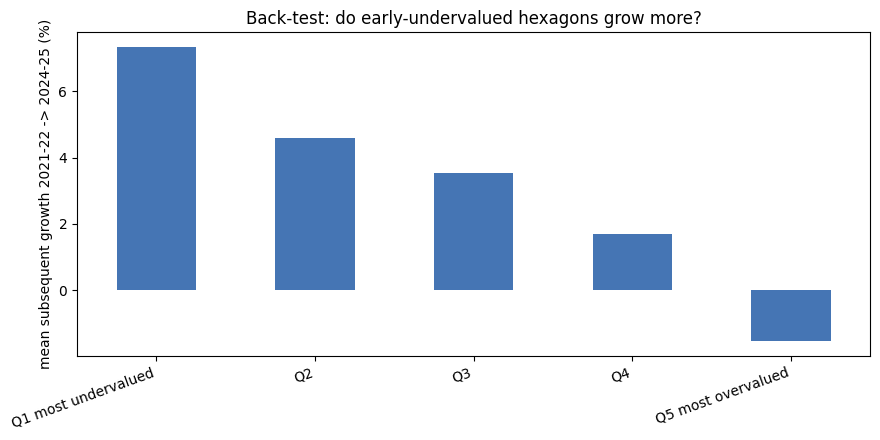

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from xgboost import XGBRegressor

PROC = "C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/data/processed"

def norm_pc(s):
    return s.astype("string").str.upper().str.replace(r"\s+", "", regex=True)

# Map pooled sales to hexagons, split into early (2021-22) and late (2024-25) medians.
pl = pd.read_parquet(f"{PROC}/planning_processed.parquet", columns=["postcode", "h3_index"]).dropna()
pl["pc"] = norm_pc(pl["postcode"])
cof = pd.read_parquet(f"{PROC}/coffee_shops_processed.parquet", columns=["addr:postcode", "h3_index"]).dropna()
cof["pc"] = norm_pc(cof["addr:postcode"])
pc2h3 = pd.concat([pl[["pc", "h3_index"]], cof.rename(columns={"addr:postcode": "postcode"})[["pc", "h3_index"]]],
                  ignore_index=True).groupby("pc")["h3_index"].agg(lambda s: s.value_counts().idxmax())

sales = pd.read_parquet(f"{PROC}/lr_london_sales.parquet", columns=["price", "postcode", "year"]).dropna(subset=["postcode"])
sales["pc"] = norm_pc(sales["postcode"])
sales["h3_index"] = sales["pc"].map(pc2h3)
sales = sales.dropna(subset=["h3_index"])

def window_median(years):
    g = sales[sales["year"].isin(years)].groupby("h3_index")["price"]
    return pd.DataFrame({"median": g.median(), "n": g.size()})

early = window_median([2021, 2022]).add_prefix("early_")
late = window_median([2024, 2025]).add_prefix("late_")
px = early.join(late, how="inner")
px = px[(px["early_n"] >= 15) & (px["late_n"] >= 15)]
px["growth"] = px["late_median"] / px["early_median"] - 1.0

# Early-period gap: predict log(early price) from signals (incl centrality), out-of-fold.
feat = pd.read_parquet(f"{PROC}/hex_valuation_gap.parquet")  # already has dist_to_centre_km
fcols = ["total_applications", "change_of_use_count", "applications_recent", "change_of_use_ratio",
         "planning_velocity", "total_cafe_count", "independent_cafe_count",
         "cafe_to_application_ratio", "dist_to_centre_km"]
df = feat.merge(px, on="h3_index", how="inner")
X = df[fcols].astype(float)
y = np.log(df["early_median"].astype(float))
mk = lambda: XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=42)
df["early_pred"] = np.exp(cross_val_predict(mk(), X, y, cv=5))
df["early_gap"] = df["early_median"] / df["early_pred"] - 1.0

print("back-test hexagons (>=15 sales in both windows):", len(df))
r = df["early_gap"].corr(df["growth"])
print(f"corr(early_gap, subsequent_growth): {r:+.3f}   (thesis expects NEGATIVE: undervalued -> grows more)")

df["gap_quintile"] = pd.qcut(df["early_gap"], 5, labels=["Q1 most undervalued", "Q2", "Q3", "Q4", "Q5 most overvalued"])
qg = df.groupby("gap_quintile", observed=True)["growth"].mean() * 100
print("\nmean subsequent growth (%) by early-gap quintile:")
print(qg.round(1).to_string())

ax = qg.plot(kind="bar", figsize=(9, 4.5), color="#4575b4")
ax.set_ylabel("mean subsequent growth 2021-22 -> 2024-25 (%)")
ax.set_title("Back-test: do early-undervalued hexagons grow more?")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("C:/Users/Aniket/Documents/Projects/Neighbourhood_Pulse/notebooks/images/backtest.png", dpi=90)
plt.show()
